In [3]:
import os
from PIL import Image, UnidentifiedImageError
import random, matplotlib.pyplot as plt, matplotlib.image as mpimg

train_dir = "/content/drive/MyDrive/FruitinAmazon/FruitinAmazon/train"
class_names = sorted(os.listdir(train_dir))
print(f"Found {len(class_names)} classes: {class_names}")

# Check corrupted images
corrupted_images = []
for class_name in class_names:
    class_path = os.path.join(train_dir, class_name)
    for img_name in os.listdir(class_path):
        img_path = os.path.join(class_path, img_name)
        try:
            with Image.open(img_path) as img:
                img.verify()
        except (IOError, UnidentifiedImageError):
            corrupted_images.append(img_path)

print("Corrupted:", corrupted_images if corrupted_images else "None found")

Found 6 classes: ['acai', 'cupuacu', 'graviola', 'guarana', 'pupunha', 'tucuma']
Corrupted: None found


In [4]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import (Conv2D, BatchNormalization, Activation,
                                     MaxPooling2D, Dropout, Flatten, Dense)
from tensorflow.keras.models import Sequential
import numpy as np

image_size = (224, 224)
batch_size = 32

train_ds, val_ds = keras.utils.image_dataset_from_directory(
    train_dir,
    validation_split=0.2,
    subset="both",
    seed=1337,
    image_size=image_size,
    batch_size=batch_size,
)

# Data Augmentation (New Keras API - recommended)
data_augmentation_layers = [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
]

def data_augmentation(images):
    for layer in data_augmentation_layers:
        images = layer(images)
    return images

Found 90 files belonging to 6 classes.
Using 72 files for training.
Using 18 files for validation.


In [5]:
num_classes = len(class_names)  # 6 for FruitsInAmazon

model = Sequential([
    layers.Lambda(data_augmentation, input_shape=(224, 224, 3)),
    layers.Rescaling(1./255),

    # Block 1
    Conv2D(32, (3,3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2,2)), Dropout(0.25),

    # Block 2
    Conv2D(64, (3,3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2,2)), Dropout(0.25),

    # Block 3
    Conv2D(128, (3,3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2,2)), Dropout(0.25),

    # Block 4
    Conv2D(256, (3,3), padding='same', activation=None),
    BatchNormalization(), Activation('relu'),
    MaxPooling2D((2,2)), Dropout(0.25),

    Flatten(),

    # Dense layers
    Dense(512, activation=None), BatchNormalization(), Activation('relu'), Dropout(0.5),
    Dense(256, activation=None), BatchNormalization(), Activation('relu'), Dropout(0.5),

    Dense(num_classes, activation='softmax')
])

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/lambda_layer.py:65: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lambda (Lambda)                 │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 224, 224, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_2 (Activation)       │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_3 (Activation)       │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             

 Total params: 26,216,902 (100.01 MB)

 Trainable params: 26,214,406 (100.00 MB)

 Non-trainable params: 2,496 (9.75 KB)

Epoch 1/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 33s 9s/step - accuracy: 0.1667 - loss: 2.1828 - val_accuracy: 0.0556 - val_loss: 2.1173
Epoch 2/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 18s 4s/step - accuracy: 0.3750 - loss: 1.6434 - val_accuracy: 0.1111 - val_loss: 1.8741
Epoch 3/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.4444 - loss: 1.6461 - val_accuracy: 0.1111 - val_loss: 1.7704
Epoch 4/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.5278 - loss: 1.4622 - val_accuracy: 0.2222 - val_loss: 1.7372
Epoch 5/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 21s 5s/step - accuracy: 0.5694 - loss: 1.1198 - val_accuracy: 0.2222 - val_loss: 1.7181
Epoch 6/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 20s 5s/step - accuracy: 0.6389 - loss: 1.0487 - val_accuracy: 0.2222 - val_loss: 1.7069
Epoch 7/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.7361 - loss: 0.8528 - val_accuracy: 0.2222 - val_loss: 1.7433
Epoch 8/20
3/3 ━━━━━━━━━━━━━━━━━━━━ 17s 5s/step - accuracy: 0.5833 - loss: 1.2615 - val_accuracy: 0.2222 - val_loss: 1.8266
Epoch 9/

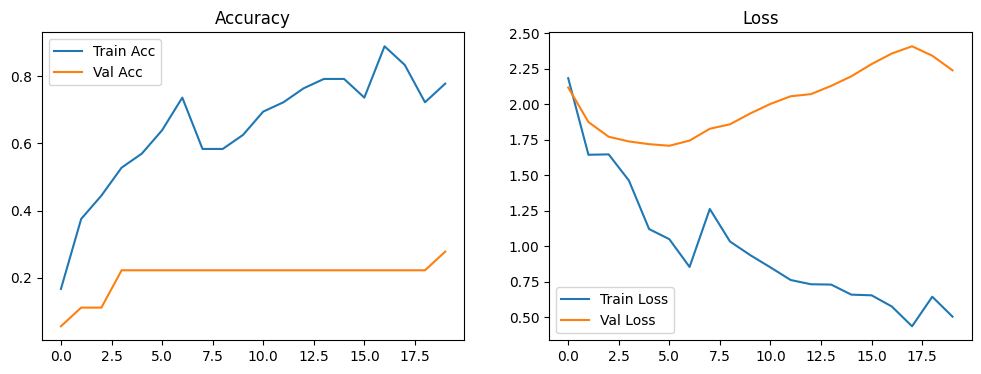

In [6]:
history = model.fit(train_ds, validation_data=val_ds, epochs=20)

# Plot accuracy & loss
plt.figure(figsize=(12,4))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Acc')
plt.plot(history.history['val_accuracy'], label='Val Acc')
plt.legend(); plt.title('Accuracy')

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend(); plt.title('Loss')
plt.show()

Task 2: Transfer Learning with VGG16
Step 1 – Load Pretrained VGG16

Step 1 – Load Pretrained VGG16


In [7]:
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

base_model = VGG16(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Step 2 – Freeze Base Layers


In [9]:
for layer in base_model.layers:
    layer.trainable = False

Step 3 – Add Custom Output Layers


In [10]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(1024, activation='relu')(x)
x = Dense(num_classes, activation='softmax')(x)   # 6 classes

tl_model = Model(inputs=base_model.input, outputs=x)

tl_model.compile(optimizer=Adam(learning_rate=0.0001),
                 loss='sparse_categorical_crossentropy',
                 metrics=['accuracy'])

Step 4 – Train and Evaluate


In [11]:
history_tl = tl_model.fit(train_ds, validation_data=val_ds, epochs=10)

# Evaluate
loss, acc = tl_model.evaluate(val_ds)
print(f"Transfer Learning Val Accuracy: {acc:.4f}")

Epoch 1/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 52s 16s/step - accuracy: 0.1528 - loss: 4.3602 - val_accuracy: 0.1667 - val_loss: 3.4347
Epoch 2/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 15s/step - accuracy: 0.2917 - loss: 2.3395 - val_accuracy: 0.2222 - val_loss: 3.2203
Epoch 3/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 81s 15s/step - accuracy: 0.5972 - loss: 1.3286 - val_accuracy: 0.2778 - val_loss: 2.8869
Epoch 4/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 47s 15s/step - accuracy: 0.7778 - loss: 0.7262 - val_accuracy: 0.3889 - val_loss: 2.6210
Epoch 5/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 82s 15s/step - accuracy: 0.8750 - loss: 0.3270 - val_accuracy: 0.2778 - val_loss: 2.6862
Epoch 6/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 48s 16s/step - accuracy: 0.9444 - loss: 0.1818 - val_accuracy: 0.3333 - val_loss: 2.8192
Epoch 7/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 0.9583 - loss: 0.1291 - val_accuracy: 0.3333 - val_loss: 2.8108
Epoch 8/10
3/3 ━━━━━━━━━━━━━━━━━━━━ 49s 16s/step - accuracy: 1.0000 - loss: 0.0756 - val_accuracy: 0.3889 - val_loss: 2.7025


Step 5 – Classification Report

In [12]:
from sklearn.metrics import classification_report
import numpy as np

y_true, y_pred = [], []
for images, labels in val_ds:
    preds = tl_model.predict(images, verbose=0)
    y_pred.extend(np.argmax(preds, axis=1))
    y_true.extend(labels.numpy())

print(classification_report(y_true, y_pred, target_names=class_names))

              precision    recall  f1-score   support

        acai       0.20      0.33      0.25         3
     cupuacu       1.00      0.50      0.67         4
    graviola       0.50      1.00      0.67         1
     guarana       0.00      0.00      0.00         1
     pupunha       0.40      0.50      0.44         4
      tucuma       0.67      0.40      0.50         5

    accuracy                           0.44        18
   macro avg       0.46      0.46      0.42        18
weighted avg       0.56      0.44      0.46        18

